In [4]:
import pandas as pd

df = pd.read_csv("loan_dataset_20000.csv")

df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [7]:
df.shape

(20000, 22)

In [8]:
df.columns

Index(['age', 'gender', 'marital_status', 'education_level', 'annual_income',
       'monthly_income', 'employment_status', 'debt_to_income_ratio',
       'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate',
       'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts',
       'total_credit_limit', 'current_balance', 'delinquency_history',
       'public_records', 'num_of_delinquencies', 'loan_paid_back'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_open_account

In [10]:
df.isnull().sum()

age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
grade_subgrade          0
num_of_open_accounts    0
total_credit_limit      0
current_balance         0
delinquency_history     0
public_records          0
num_of_delinquencies    0
loan_paid_back          0
dtype: int64

##Data Visualization##

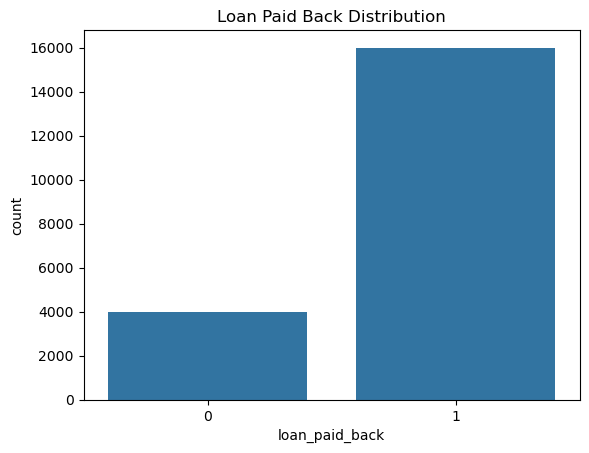

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='loan_paid_back', data=df)

plt.title("Loan Paid Back Distribution")

plt.show()

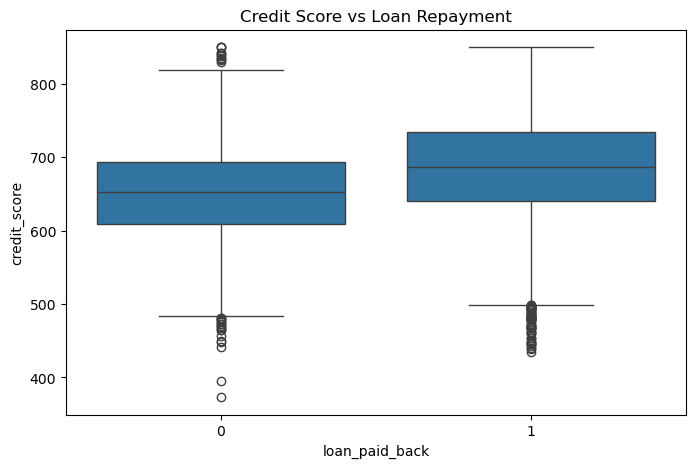

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x='loan_paid_back', y='credit_score', data=df)

plt.title("Credit Score vs Loan Repayment")

plt.show()

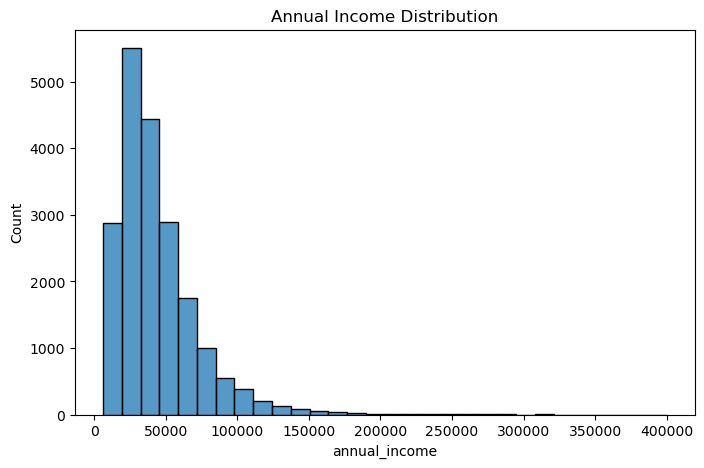

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['annual_income'], bins=30)

plt.title("Annual Income Distribution")

plt.show()

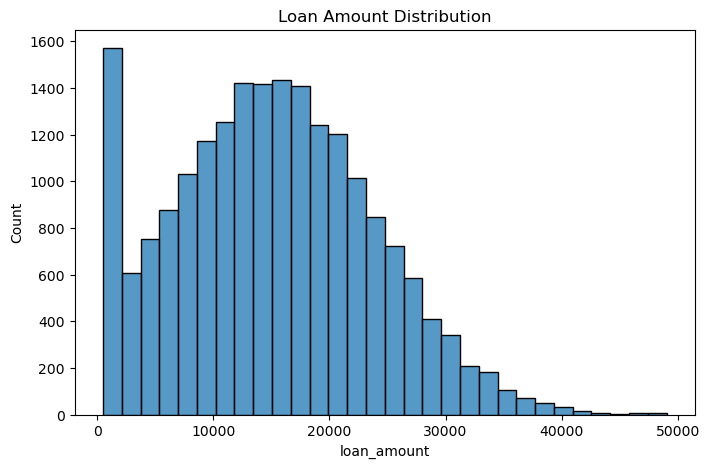

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['loan_amount'], bins=30)

plt.title("Loan Amount Distribution")

plt.show()

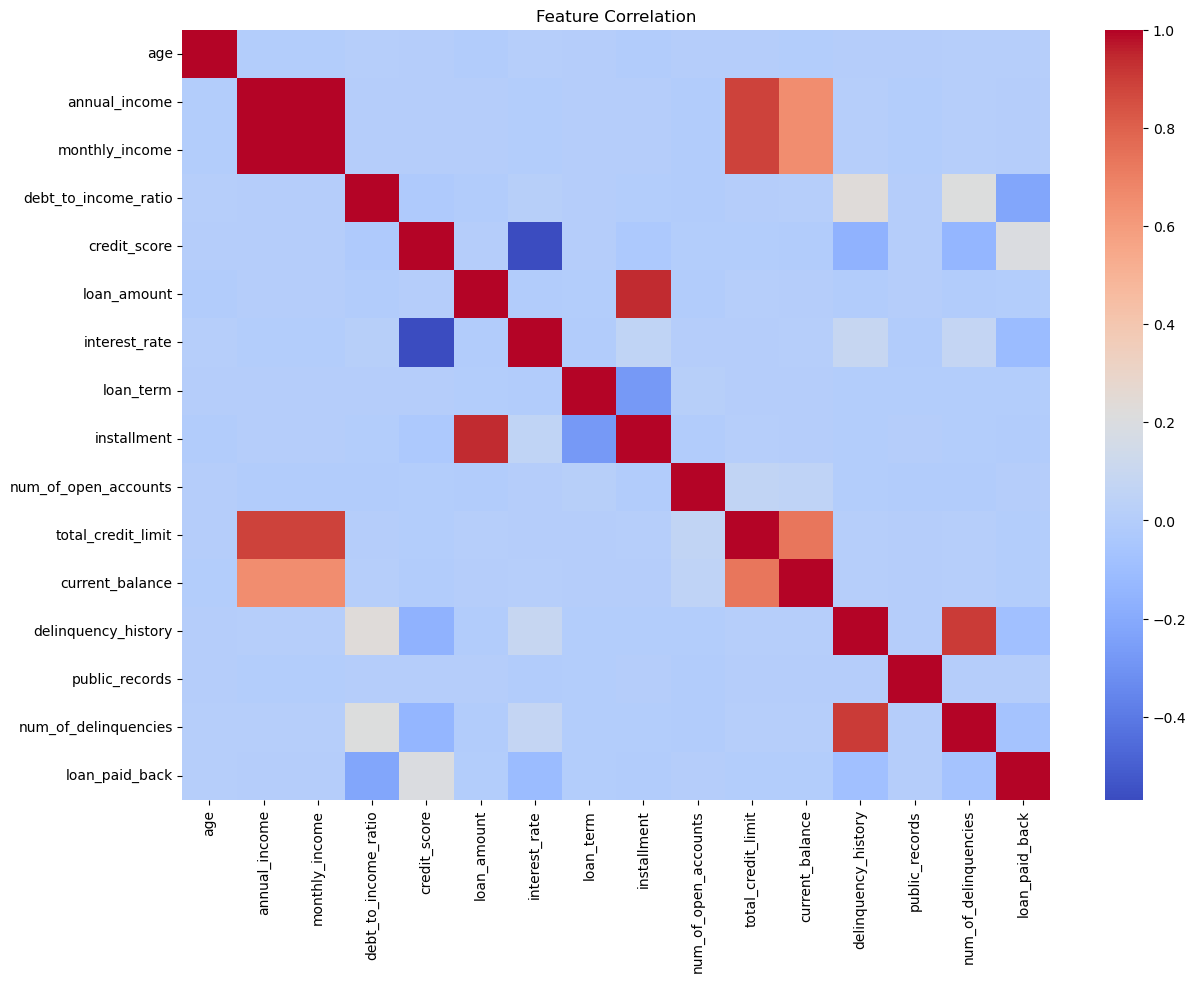

In [15]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

In [16]:
categorical_cols = df.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')


In [17]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.head()

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,...,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5
0,59,24240.19,2020.02,0.074,743,17173.72,13.39,36,581.88,7,...,False,False,False,False,False,False,False,False,False,False
1,72,20172.98,1681.08,0.219,531,22663.89,17.81,60,573.17,5,...,False,False,False,False,False,True,False,False,False,False
2,49,26181.80,2181.82,0.234,779,3631.36,9.53,60,76.32,2,...,False,False,False,False,False,False,False,False,False,False
3,35,11873.84,989.49,0.264,809,14939.23,7.99,36,468.07,7,...,False,False,False,False,False,False,False,False,False,False
4,63,25326.44,2110.54,0.260,663,16551.71,15.20,60,395.50,1,...,False,False,False,False,False,False,False,False,False,False


In [18]:
X = df_encoded.drop("loan_paid_back", axis=1)

y = df_encoded["loan_paid_back"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (16000, 64)
Testing Data: (4000, 64)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_acc = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.79175


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.83325


In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8935


In [24]:
print("Logistic Regression:", log_acc)
print("Decision Tree:", dt_acc)
print("Random Forest:", rf_acc)

Logistic Regression: 0.79175
Decision Tree: 0.83325
Random Forest: 0.8935


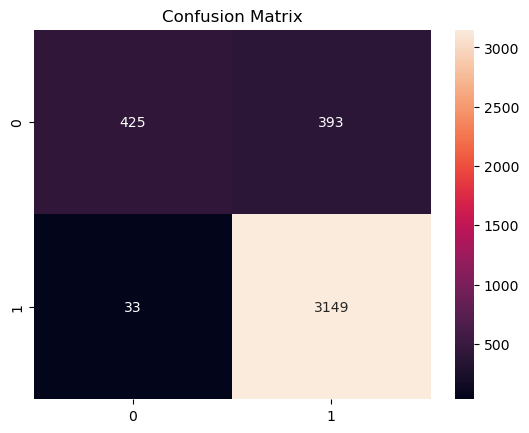

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.show()

In [26]:
import pickle

pickle.dump(rf_model, open("loan_model.pkl", "wb"))